# Return curves of each option and env reward

In [126]:
# get data - download and store locally 
import wandb
import os
from dotenv import load_dotenv
# load environment variables from .env file
load_dotenv()
# use .env for the api key
api_key =  os.getenv("WANDB_API_KEY")
api = wandb.Api(api_key=api_key)
# run = api.run("raban-emunds-tu-darmstadt/uncategorized/runs/g304pm83") 
# run = api.run("raban-emunds-tu-darmstadt/uncategorized/runs/4nimiw1j") 
# run = api.run("raban-emunds-tu-darmstadt/SymbolicOptions/runs/7vwud27u") 

In [137]:
import pandas as pd
import numpy as np


def get_algorithm_from_name(name):
    if "comb" in name:
        return "Soft meta-policy"
    elif "llm" in name:
        return "Fixed meta-policy"
    elif "pre" in name:
        return "Soft meta-policy with pretraining"
    elif "hier" in name:
        return "HPQN"
    if "pqn" in name:
        return "PQN"
    else:
        return "Unknown"

In [227]:

def get_run_data(runs, craftax=False):
    data = []
    for run in runs:
        run = api.run(runs[run])
        print("quering run: ", run.id)
        run_data= run.history()
        # run_data_full = run.history()
        seeds = list(set([key.split("/")[0] for key in run_data.keys() if "rng" in key]))
        # key_list = ["returned_episode_env_returns", "returned_episode_returns_0", "returned_episode_returns_1", "returned_episode_returns_2", "test/returned_episode_env_returns", "test_modif/returned_episode_env_returns"]
        # key_list = [seed + "/" + key for seed in seeds for key in key_list]
        # key_list.append("_step")
        # run_data = run_data_full.loc[:, key_list]

        x_data = run_data["_step"].to_numpy() / 1000
        def get_seed_data(seed):
            env_ret = run_data[seed + "/returned_episode_env_returns"].to_numpy()
            test_env_ret = run_data[seed + "/test/returned_episode_env_returns"].to_numpy()
            if not craftax:
                modif_test_env_ret = run_data[seed + "/test_modif/returned_episode_env_returns"].to_numpy()
            else:
                score = run_data[seed + "/score"].to_numpy()
                test_score = run_data[seed + "/test/score"].to_numpy()


            # opt_rets = {}
            opt_rets = []
            option_strs = ["returned_episode_returns_0", "returned_episode_returns_1", "returned_episode_returns_2"]
            for opt_str in option_strs:
                ret = run_data[seed + "/" + opt_str].to_numpy()
                test_ret = run_data[seed + "/test/" + opt_str].to_numpy()
                if not craftax:
                    modif_test_ret = run_data[seed + "/test_modif/" + opt_str].to_numpy()
                    opt_rets += [ret, test_ret, modif_test_ret]
                else:
                    opt_rets += [ret, test_ret]
            if not craftax:
                return env_ret, test_env_ret, modif_test_env_ret, *opt_rets
            else:
                return env_ret, test_env_ret, score, test_score, *opt_rets
            
        all_data = np.array([get_seed_data(seed) for seed in seeds])

        if not craftax:
            row = {
                "run_id": run.id,
                "run_name": run.name,
                "seeds": seeds, 
                "algorithm": get_algorithm_from_name(run.name),
                "x_data": x_data,
                "env_ret": all_data[:, 0],
                "test_env_ret": all_data[:, 1],
                "modif_test_env_ret": all_data[:, 2],
                "opt0_ret": all_data[:, 3],
                "test_opt0_ret": all_data[:, 4],
                "modif_test_opt0_ret": all_data[:, 5],
                "opt1_ret": all_data[:, 6],
                "test_opt1_ret": all_data[:, 7],
                "modif_test_opt1_ret": all_data[:, 8],
                "opt2_ret": all_data[:, 9],
                "test_opt2_ret": all_data[:, 10],
                "modif_test_opt2_ret": all_data[:, 11],
            }
        else:
            row = {
                "run_id": run.id,
                "run_name": run.name,
                "seeds": seeds, 
                "algorithm": get_algorithm_from_name(run.name),
                "x_data": x_data,
                "env_ret": all_data[:, 0],
                "test_env_ret": all_data[:, 1],
                "score": all_data[:, 2],
                "test_score": all_data[:, 3],
                "opt0_ret": all_data[:, 4],
                "test_opt0_ret": all_data[:, 5],
                "opt1_ret": all_data[:, 6],
                "test_opt1_ret": all_data[:, 7],
                "opt2_ret": all_data[:, 8],
                "test_opt2_ret": all_data[:, 9],
            }

        data.append(row)
    df = pd.DataFrame(data)
    return df

# Seaquest 
seaquest_run_ids = {
    "pqn": "anikav8n",
    "hpqn": "9cot8a25",
    "llm": "ivxucgak",
    "comb": "wwaym6rm", # this is the new one
    # "comb": "nc3i9b6e", #TODO: change
    "comb_pre": "s9ode17q"
}

seaquest_runs = {
    run_id: f"raban-emunds-tu-darmstadt/SymbolicOptionsFinal/runs/{run_hash}" for run_id , run_hash in seaquest_run_ids.items()
}
seaquest_df = get_run_data(seaquest_runs)

# Kangaroo 
kangaroo_run_ids = {
    "pqn": "g3fyf8qm",
    "hpqn": "jd7zgepa",
    "llm": "kk3s3oou",
    "comb": "5983jobq", 
    "comb_pre": "5whpom4g"
}

kangaroo_runs = {
    run_id: f"raban-emunds-tu-darmstadt/SymbolicOptionsFinal/runs/{run_hash}" for run_id , run_hash in kangaroo_run_ids.items()
}

kangaroo_df = get_run_data(kangaroo_runs)

# craftax 
craftax_run_ids = {
    "pqn": "2sgxb9yv",
    "hpqn": "2oy51ht2",
    "llm": "7w8sbe6r",
    "comb": "90yv7key", 
    "comb_pre": "25ka3ljp"
}

craftax_runs = {
    run_id: f"raban-emunds-tu-darmstadt/SymbolicOptionsFinal/runs/{run_hash}" for run_id , run_hash in craftax_run_ids.items()
}

craftax_df = get_run_data(craftax_runs, True)

quering run:  anikav8n
quering run:  9cot8a25
quering run:  ivxucgak
quering run:  wwaym6rm
quering run:  s9ode17q
quering run:  g3fyf8qm
quering run:  jd7zgepa
quering run:  kk3s3oou
quering run:  5983jobq
quering run:  5whpom4g
quering run:  2sgxb9yv
quering run:  2oy51ht2
quering run:  7w8sbe6r
quering run:  90yv7key
quering run:  25ka3ljp


In [234]:
kangaroo_df

,run_id,run_name,seeds,algorithm,x_data,env_ret,test_env_ret,modif_test_env_ret,opt0_ret,test_opt0_ret,modif_test_opt0_ret,opt1_ret,test_opt1_ret,modif_test_opt1_ret,opt2_ret,test_opt2_ret,modif_test_opt2_ret,game
0,g3fyf8qm,pqn_Kangaroo,"[rng2467461003, rng3186719485, rng2562233961]",PQN,"[0.005, 0.016, 0.019, 0.043, 0.049, 0.081, 0.0...","[[1.2969970703125, 6.95343017578125, 8.3969116...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[1.2945175170898438, 1.3088226318359375, 1.23...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[-6.0, -6.0, -6.0, -6.0, -6.0, -6.0, -6.0, -6...","[[-0.5766677856445312, -0.9591751098632812, -0...","[[-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1...","[[-3.0, -3.0, -3.0, -3.0, -3.0, -3.0, -3.0, -3...","[[0.0, 0.0, 0.00164794921875, 0.0009765625, 0....","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",Kangaroo
1,jd7zgepa,pqn_hier_Kangaroo,"[rng2467461003, rng3186719485, rng2562233961]",HPQN,"[0.021, 0.024, 0.039, 0.067, 0.081, 0.084, 0.0...","[[5.50537109375, 6.4971923828125, 7.5698852539...","[[5.661214351654053, 5.661214351654053, 5.6612...","[[59.521484375, 59.521484375, 59.521484375, 59...","[[1.7644424438476562, 1.4957046508789062, 1.76...","[[1.5113945007324219, 1.5113945007324219, 1.51...","[[7.65673828125, 7.65673828125, 7.65673828125,...","[[-0.9700088500976562, -0.9661026000976562, -0...","[[-0.969947338104248, -0.969947338104248, -0.9...","[[-3.0, -3.0, -3.0, -3.0, -3.0, -3.0, -3.0, -3...","[[0.0, 0.0, 0.0009765625, 0.0, 0.0, 0.0, 0.000...","[[0.0002772386942524463, 0.0002772386942524463...","[[0.59521484375, 0.59521484375, 0.59521484375,...",Kangaroo
2,kk3s3oou,pqn_hier_llm_Kangaroo,"[rng2467461003, rng3186719485, rng2562233961]",Fixed meta-policy,"[0.012, 0.023, 0.024, 0.05, 0.086, 0.09, 0.1, ...","[[4.4586181640625, 6.829833984375, 5.200195312...","[[5.661214351654053, 5.661214351654053, 5.6612...","[[59.521484375, 59.521484375, 59.521484375, 59...","[[1.7670211791992188, 1.6527633666992188, 1.52...","[[1.5113945007324219, 1.5113945007324219, 1.51...","[[7.65673828125, 7.65673828125, 7.65673828125,...","[[-0.9768218994140625, -0.9622344970703125, -0...","[[-0.969947338104248, -0.969947338104248, -0.9...","[[-3.0, -3.0, -3.0, -3.0, -3.0, -3.0, -3.0, -3...","[[0.0, 0.0, 0.0, 0.0, 0.0020751953125, 0.00195...","[[0.0002772386942524463, 0.0002772386942524463...","[[0.59521484375, 0.59521484375, 0.59521484375,...",Kangaroo
3,5983jobq,pqn_hier_comb_Kangaroo,"[rng2467461003, rng3186719485, rng2562233961]",Soft meta-policy,"[0.002, 0.005, 0.011, 0.028, 0.039, 0.044, 0.0...","[[0.0, 2.35748291015625, 4.5196533203125, 7.17...","[[5.661214351654053, 5.661214351654053, 5.6612...","[[59.521484375, 59.521484375, 59.521484375, 59...","[[0.0, 1.40191650390625, 1.6708145141601562, 1...","[[1.5113945007324219, 1.5113945007324219, 1.51...","[[7.65673828125, 7.65673828125, 7.65673828125,...","[[0.0, -0.5990066528320312, -0.976882934570312...","[[-0.969947338104248, -0.969947338104248, -0.9...","[[-3.0, -3.0, -3.0, -3.0, -3.0, -3.0, -3.0, -3...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0009765625, 0.0, ...","[[0.0002772386942524463, 0.0002772386942524463...","[[0.59521484375, 0.59521484375, 0.59521484375,...",Kangaroo
4,5whpom4g,pqn_hier_comb_pre_Kangaroo,"[rng2467461003, rng3186719485, rng2562233961]",Soft meta-policy,"[0.002, 0.009, 0.028, 0.058, 0.089, 0.097, 0.0...","[[0.0, 5.01251220703125, 6.3385009765625, 6.13...","[[5.661214351654053, 5.661214351654053, 5.6612...","[[59.521484375, 59.521484375, 59.521484375, 59...","[[0.0, 1.7579727172851562, 1.6485137939453125,...","[[1.5113945007324219, 1.5113945007324219, 1.51...","[[7.65673828125, 7.65673828125, 7.65673828125,...","[[0.0, -0.9739608764648438, -0.966651916503906...","[[-0.969947338104248, -0.969947338104248, -0.9...","[[-3.0, -3.0, -3.0, -3.0, -3.0, -3.0, -3.0, -3...","[[0.0, 0.0, 0.0, 0.0, 0.001953125, 0.000976562...","[[0.0002772386

In [229]:
# plot using plt
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.cm as cm
from tueplots import bundles, axes
from matplotlib import cm

plt.rcParams.update({"figure.dpi": 150})


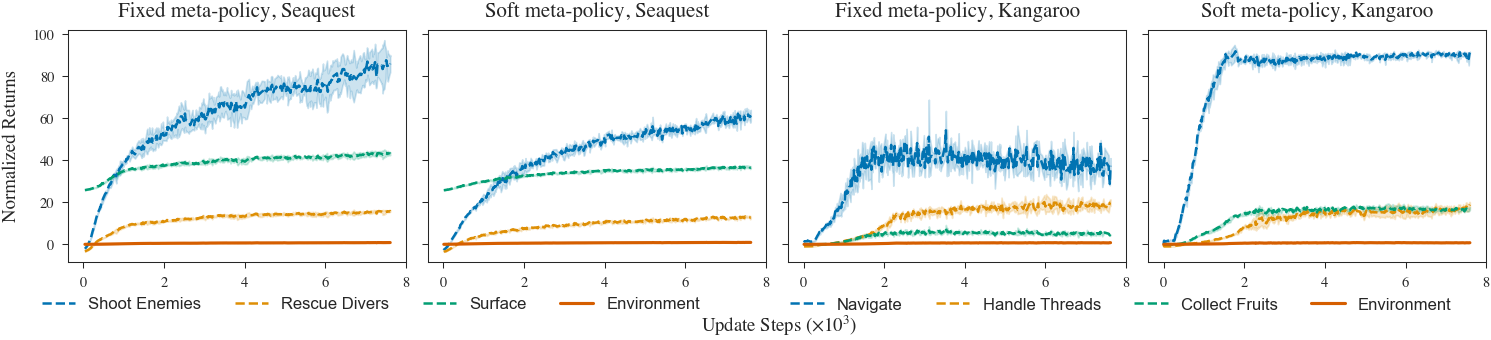

In [230]:
def single_run_plot(ax1, df, run_name, option_labels, num):
    # colors = cm.get_cmap("tab10")
    row = df[df["run_name"] == run_name].iloc[0]

    # sns.set_context("paper")
    sns.set_theme(context="paper", style="ticks")
    colors = sns.color_palette("colorblind")
    # with plt.rc_context({**bundles.neurips2024(usetex=False), **axes.lines()}):
    # fig, ax1 = plt.subplots()
    x_data = row["x_data"]
    is_kang = int(num > 1)
    for i, label in enumerate(option_labels):
        option_mean = row[f"opt{i}_ret"].mean(axis=0)
        option_std = row[f"opt{i}_ret"].std(axis=0)
        ax1.plot(x_data, option_mean, label=label, color=colors[i], zorder=1, linestyle="--") 
        ax1.fill_between(x_data, option_mean - option_std, option_mean + option_std, color=colors[i], alpha=0.2, zorder=0)
    # ax1.set_xlabel("Update Steps ($\\times 10^3$)")
    # ax1.set_ylabel("Normalized Skill Returns")

    # Create a second y-axis for the environment reward
    # ax2 = ax1.twinx()
    env_norm = row["env_ret"] / row["env_ret"].max()
    env_mean = env_norm.mean(axis=0)
    env_std = env_norm.std(axis=0)
    ax1.plot(x_data, env_mean, label="Environment", color=colors[i+1], zorder=2, linewidth=1.5)
    ax1.fill_between(x_data, env_mean - env_std, env_mean + env_std, color=colors[i+1], alpha=0.2, zorder=0)
    # remove data from ax2
    # ax2.axhline(max(env_mean), color=colors[i+1], linestyle="--", alpha=1.0, zorder=1)
    # ax2.set_ylabel("Environment Return")
    
    # Combine legends from both axes and ensure they are drawn on top of the lines
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    # lines_2, labels_2 = ax2.get_legend_handles_labels()
    
    # set title
    game_name = "Seaquest" if num < 2 else "Kangaroo"
    ax1.set_title(f"{get_algorithm_from_name(run_name)}, {game_name}", fontsize=10)
    # legend = ax1.legend(lines_1 + lines_2, labels_1 + labels_2)#, ncol=2)
    # legend = ax1.legend(lines_2 + lines_1, labels_2 + labels_1)#, ncol=2)
    # legend.set_zorder(3)  # Ensure the legend is drawn on top of the lines
    
    # plt.title("Skill and Environment Returns")
    # plt.tight_layout()
    # plt.savefig(f"{run_name}_skills.pdf", bbox_inches="tight")
    # plt.show()
    return lines_1, labels_1 

def plot_all_runs():
    with plt.rc_context({**bundles.neurips2024(usetex=False), **axes.lines()}):
        fig, ax = plt.subplots(nrows=1, ncols=4, sharex=True, sharey=True, constrained_layout=True, figsize=(10, 2))

        runs = [
            (seaquest_df, "pqn_hier_llm_Seaquest", ["Shoot Enemies", "Rescue Divers", "Surface"]),
            (seaquest_df, "pqn_hier_comb_Seaquest", ["Shoot Enemies", "Rescue Divers", "Surface"]),
            (kangaroo_df, "pqn_hier_llm_Kangaroo", ["Navigate", "Handle Threads", "Collect Fruits"]),
            (kangaroo_df, "pqn_hier_comb_Kangaroo", ["Navigate", "Handle Threads", "Collect Fruits"]),
        ]
        handles, labels = [], []
        for i, (ax, (df, run_name, labels)) in enumerate(zip(ax.flatten(), runs)):
            h, l = single_run_plot(ax, df, run_name, labels, i)
            if i % 2 == 0:
                # fig.legend(unique.values(), unique.keys(), bbox_to_anchor=(0.5, -0.03), loc="center", ncol=8, frameon=False, fontsize="small")
                x = 0.25 if i == 0 else 0.75
                fig.legend(h, l, bbox_to_anchor=(x, -0.03), loc="center", ncol=8, frameon=False, fontsize="small")
        # Shared axis labels (only on the figure level)
        config = bundles.neurips2024(usetex=False)#["font"]
        # fig.supxlabel("Update Steps ($\\times 10^3$)", family=config["font.family"], size=config["font.size"])
        fig.supylabel("Normalized Returns", family=config["font.family"], size=config["font.size"])
        # fig.text(1, 0.5, "Environment Return", va="center", rotation=90, family=config["font.family"], size=config["font.size"]) 
        fig.text(0.47, -0.1, "Update Steps ($\\times 10^3$)", va="center", rotation=0, family=config["font.family"], size=config["font.size"]) 

        plt.savefig("skill_returns.pdf", bbox_inches="tight")
        plt.show()
plot_all_runs()
# TODO: two legends, equal y axis limits

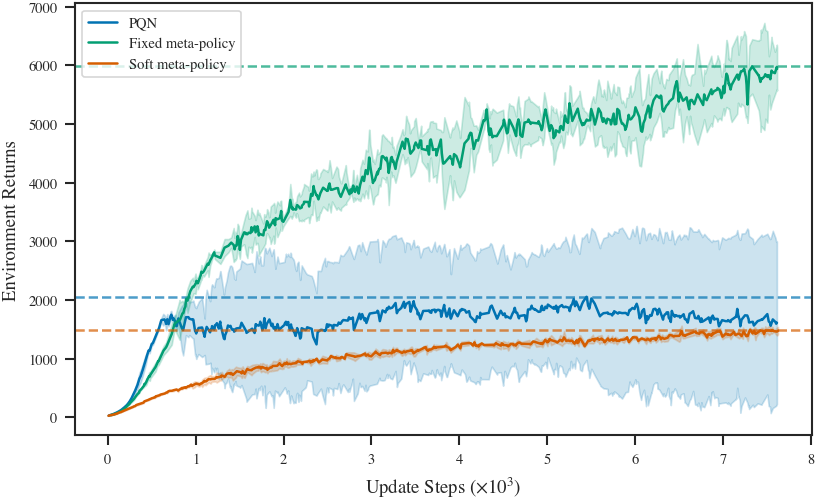

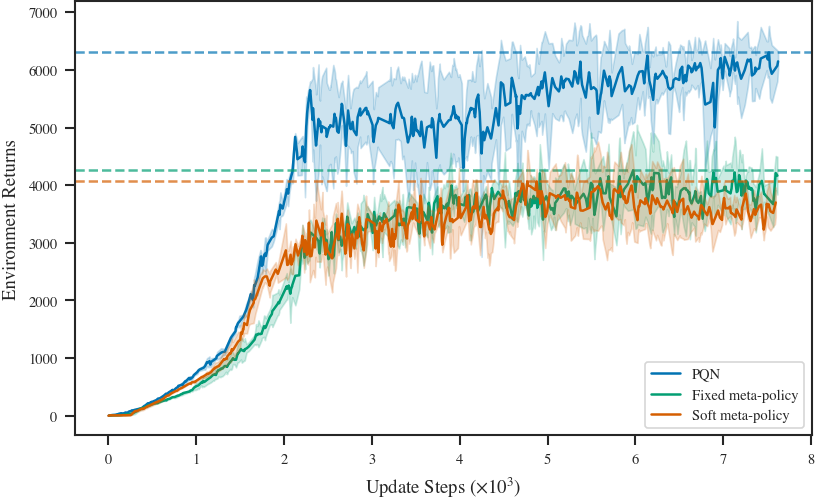

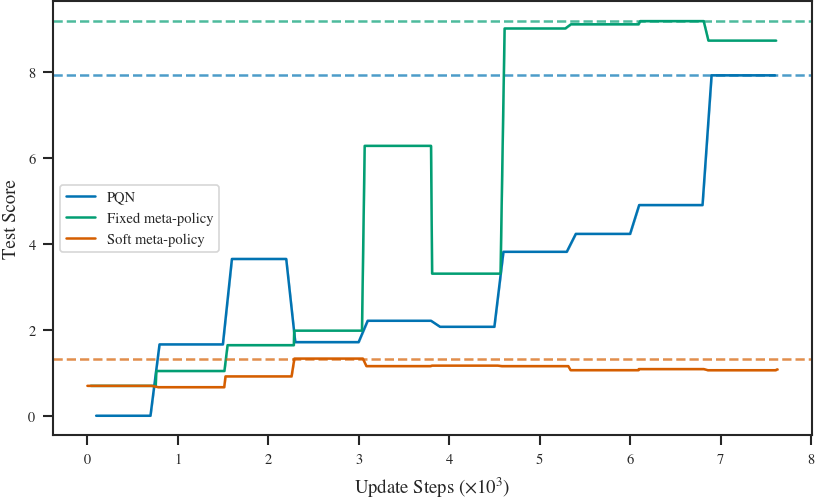

In [231]:
def comparison_plot(df, run_names):
    # Set the style
    sns.set_theme(context="paper", style="ticks")
    colors = sns.color_palette("colorblind")
    # Create a figure and axis
    with plt.rc_context(bundles.neurips2024(usetex=False)):
        fig, ax = plt.subplots()
        # Plot the data
        df1 = df[df["run_name"].isin(run_names)]
        for i, row in df1.iterrows():
            # ax.plot(row["env_ret"][0], label=row["algorithm"], color=colors(i), zorder=1)
            # ax.axhline(row["env_ret"][0].max(), color=colors(i), linestyle="--", alpha=0.7, zorder=1)
            # use plt to plot data across multiple seeds
            step = row["x_data"]
            mean = np.mean(row["env_ret"], axis=0)
            std = np.std(row["env_ret"], axis=0)
            if "Craftax" in run_names[0]:
                mean = np.mean(row["test_score"], axis=0)
                std = np.std(row["test_score"], axis=0)
            ax.plot(step, mean, label=row["algorithm"], color=colors[i], zorder=1)
            ax.fill_between(step, mean - std, mean + std, alpha=0.2, color=colors[i], zorder=1)
            ax.axhline(mean.max(), color=colors[i], linestyle="--", alpha=0.7, zorder=1)

        # Set the labels and title
        ax.set_xlabel("Update Steps ($\\times 10^3$)") 
        ax.set_ylabel("Environment Returns")
        if "Craftax" in run_names[0]:
            ax.set_ylabel("Test Score")
        # Add a legend
        ax.legend()
        # Show the plot
        # plt.tight_layout()
        name = run_names[0].split("_")[-1]
        plt.savefig(f"{name}_comparison.pdf", bbox_inches="tight")
        plt.show()
# comparison_plot(seaquest_df, ["pqn_Seaquest", "pqn_hier_Seaquest", "pqn_hier_llm_Seaquest", "pqn_hier_comb_Seaquest"])
# comparison_plot(kangaroo_df, ["pqn_Kangaroo", "pqn_hier_Kangaroo", "pqn_hier_llm_Kangaroo", "pqn_hier_comb_Kangaroo"])
# comparison_plot(craftax_df, ["pqn_Craftax-Classic-Symbolic-v1", "pqn_hier_Craftax-Classic-Symbolic-v1", "pqn_hier_llm_Craftax-Classic-Symbolic-v1", "pqn_hier_llm_comb_Craftax-Classic-Symbolic-v1"])
comparison_plot(seaquest_df, ["pqn_Seaquest", "pqn_hier_llm_Seaquest", "pqn_hier_comb_Seaquest"])
comparison_plot(kangaroo_df, ["pqn_Kangaroo", "pqn_hier_llm_Kangaroo", "pqn_hier_comb_Kangaroo"])
comparison_plot(craftax_df, ["pqn_Craftax-Classic-Symbolic-v1", "pqn_hier_llm_Craftax-Classic-Symbolic-v1", "pqn_hier_llm_comb_Craftax-Classic-Symbolic-v1"])

Game: Seaquest
maxes: [np.float64(2050.551717122396), np.float64(5235.645182291667), np.float64(1384.7018636067708)]
maxes2: [np.float64(1660.0), np.float64(15381.616861979166), np.float64(4365.039876302083)]
max_val: 15381.616861979166
pqn_max: 2050.551717122396
Algo: pqn
non_modmean_max: 2050.551717122396
modmean_max: 0.0
other_modmean_max: 3320.0
Algo: pqn_hier_llm
non_modmean_max: 5235.645182291667
modmean_max: 13564.448567708334
other_modmean_max: 22137.62890625
Algo: pqn_hier_comb
non_modmean_max: 1384.7018636067708
modmean_max: 3924.281046549479
other_modmean_max: 6823.42041015625
Game: Kangaroo
maxes: [np.float64(11300.0), np.float64(3860.51123046875), np.float64(3984.364501953125)]
maxes2: [np.float64(500.0), np.float64(2702.6204427083335), np.float64(1349.977294921875)]
max_val: 11300.0
pqn_max: 11300.0
Algo: pqn
non_modmean_max: 11300.0
modmean_max: 300.0
other_modmean_max: 600.0
Algo: pqn_hier_llm
non_modmean_max: 3860.51123046875
modmean_max: 1330.9709879557292
other_modme

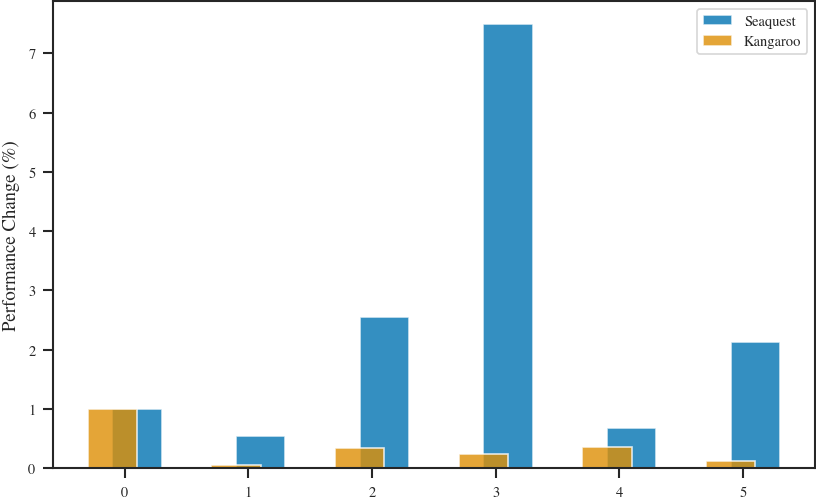

In [250]:
# What about distribution shifts? How do they handle them?

def distribution_shift_plot(df, performance_col, games, algos):
    sns.set_theme(context="paper", style="ticks")
    colors = sns.color_palette("colorblind")
    with plt.rc_context(bundles.neurips2024(usetex=False)):
        width = 0.4  # narrower bars to fit more
        fig, ax = plt.subplots()

        x = np.arange(len(algos)*2)  # one x-tick per algorithm


        # For each game and mod condition, plot bars offset from center
        for i, game in enumerate(games):
            print(f"Game: {game}")
            perf_means = []
            perf_stds = []

            maxes = [np.nanmax(np.nanmean(df[df["run_name"] == f"{algo}_{game}"][f"{performance_col[i]}"].iloc[0], axis=0)) for algo in algos]
            maxes2 = [np.nanmax(np.nanmean(df[df["run_name"] == f"{algo}_{game}"][f"modif_{performance_col[i]}"].iloc[0], axis=0)) for algo in algos]
            print(f"maxes: {maxes}")
            print(f"maxes2: {maxes2}")
            max_val = np.nanmax(maxes+maxes2)
            print(f"max_val: {max_val}")
            pqn_max = np.nanmax(np.nanmean(df[df["run_name"] == f"pqn_{game}"][f"{performance_col[i]}"].iloc[0], axis=0))
            print(f"pqn_max: {pqn_max}")

            for algo in algos:
                print(f"Algo: {algo}")
                # Get performance change = (modified_max - original_max) / original_max
                # Non-modified
                # again select the run with the maximum environment performance
                non_mod = df[df["run_name"] == f"{algo}_{game}"][f"{performance_col[i]}"].iloc[0] #(n_seeds, n_steps)
                # replace nans with median
                non_mod = np.nan_to_num(non_mod, nan=np.nanmedian(non_mod))
                max_idx = np.nanmean(non_mod, axis=0).argmax() # (1,)
                # max_idx = non_mod.argmax(axis=1) # (n_seeds,)
                non_mod_mean_max = np.nanmean(non_mod, axis=0)[max_idx] 
                print(f"non_modmean_max: {non_mod_mean_max}")
                non_mod_std = np.nanstd(non_mod, axis=0)[max_idx]

                # Modified
                # mod = df[df["run_name"] == f"{algo}_modifs_{game}"]["test_env_ret"].iloc[0]
                # Measure performance change when modified
                mod = df[df["run_name"] == f"{algo}_{game}"][f"modif_{performance_col[i]}"].iloc[0]
                mod = np.nan_to_num(mod, nan=np.nanmedian(mod))
                # print("mod what? max: ", mod[1].max())
                assert mod.shape == non_mod.shape, f"Shape mismatch: {mod.shape} vs {non_mod.shape}"

                # print(f"modmean: {np.nanmean(mod, axis=0)}")
                mod_mean_max = np.nanmean(mod, axis=0)[max_idx]
                print(f"modmean_max: {mod_mean_max}")
                mod_mean_max = np.nanmax(np.nanmean(mod, axis=0))
                print(f"other_modmean_max: {np.max(mod)}")
                mod_std = np.nanstd(mod, axis=0)[max_idx]

                perf_means.append(non_mod_mean_max / pqn_max)
                perf_means.append(mod_mean_max / pqn_max)
                perf_stds.append(non_mod_std)
                perf_stds.append(mod_std)

            # Shift bars to the left and right based on game index
            if i % 2 == 0:
                pos = x + width/4
            else:
                pos = x - width/4
            # ax.bar(pos, perf_change_means, yerr=perf_change_stds, capsize=5, width=width, 
            #     label=f"{game}", color=colors[i], alpha=0.8)
            # ax.set_yscale("log")
            # ax.bar(pos, perf_means, yerr=perf_stds, capsize=5, width=width, 
            #     label=f"{game}", color=colors[i], alpha=0.8)
            ax.bar(pos, perf_means, width=width, 
                label=f"{game}", color=colors[i], alpha=0.8)

        ax.set_xticks(x)
        algo_names = [get_algorithm_from_name(algo) for algo in algos]
        # ax.set_xticklabels(algo_names)
        ax.set_ylabel("Performance Change (%)")
        # ax.set_title("Performance Change under Distribution Shift")
        ax.legend()
        plt.show()

seaquest_df["game"] = "Seaquest"
kangaroo_df["game"] = "Kangaroo"
both_df = pd.concat([seaquest_df, kangaroo_df], ignore_index=True)
# distribution_shift_plot(combined_df, ["Seaquest"], ["pqn_hier_llm"])
# This is what we want to plot later
distribution_shift_plot(both_df, ["test_env_ret", "test_env_ret"], ["Seaquest", "Kangaroo"], ["pqn", "pqn_hier_llm", "pqn_hier_comb"])
# distribution_shift_plot(both_df, ["test_opt1_ret", "test_opt0_ret"], ["Seaquest", "Kangaroo"], ["pqn", "pqn_hier_llm", "pqn_hier_comb"])
        